Paso 1: Inicialización del Repositorio y Entorno de Trabajo.

In [4]:
import os

# Definir la estructura de carpetas requerida
estructura = [
    "data/raw",
    "data/processed",
    "notebooks",
    "app/pages",
    "reports",
    "logs"
]

for carpeta in estructura:
    os.makedirs(carpeta, exist_ok=True)
    print(f"Carpeta creada o ya existente: {carpeta}")

# Crear los archivos vacíos iniciales
archivos_iniciales = [
    "README.md",
    "requirements.txt",
    "logs/pipeline_log.csv",
    "app/Home.py",
    "app/pages/01_Dataset.py",
    "app/pages/02_EDA.py",
    "app/pages/03_PCA.py",
    "app/pages/04_Conclusiones.py"
]

for archivo in archivos_iniciales:
    if not os.path.exists(archivo):
        with open(archivo, 'w') as f:
            pass
        print(f"Archivo creado: {archivo}")

Carpeta creada o ya existente: data/raw
Carpeta creada o ya existente: data/processed
Carpeta creada o ya existente: notebooks
Carpeta creada o ya existente: app/pages
Carpeta creada o ya existente: reports
Carpeta creada o ya existente: logs


Paso 2: Definición de Objetivos y Preguntas de Negocio.

Pregunta 1 (Univariado): ¿Cómo es la distribución de los costos médicos (charges) en la población evaluada? ¿Existe un sesgo pronunciado?

Pregunta 2 (Bivariado): ¿Existe una diferencia significativa en los costos médicos entre los pacientes fumadores y no fumadores?

Pregunta 3 (Bivariado): ¿Cómo se correlaciona el Índice de Masa Corporal (bmi) con los costos médicos generados?

Pregunta 4 (Multivariado): ¿De qué manera interactúan el estado de fumador y el IMC para impactar en los costos médicos de los pacientes?

Paso 3: Perfilado de Datos e Inspección de Calidad Inicial (o Data Profiling).

In [15]:
# %% [markdown]
# # 01. Inspección Inicial del Dataset de Clínica Médica
# Este notebook cumple con el objetivo de comprender la estructura y calidad inicial de los datos.

# %%
import os
import pandas as pd

# Listado de posibles rutas para evitar el FileNotFoundError
posibles_rutas = [
    '../data/raw/reporte_clinica.csv',
    '../data/raw/reporte_clinica (3).csv',
    'data/raw/reporte_clinica.csv',
    'data/raw/reporte_clinica (3).csv',
    'reporte_clinica (3).csv'
]

df_raw = None
for ruta in posibles_rutas:
    if os.path.exists(ruta):
        # index_col=0 se usa porque la primera columna del CSV es el índice original sin nombre
        df_raw = pd.read_csv(ruta, index_col=0)
        print(f"✅ ¡Dataset cargado con éxito desde: {ruta}!\n")
        break

if df_raw is None:
    raise FileNotFoundError(
        "❌ No se encontró el archivo CSV en ninguna de las rutas esperadas.\n"
        "Por favor, asegúrate de colocar el archivo 'reporte_clinica (3).csv' "
        "en la raíz de tu proyecto o dentro de la carpeta 'data/raw/'"
    )

# %%
# 1. Dimensiones del dataset
print("==================================================")
print(f" Dimensiones iniciales: {df_raw.shape[0]} filas y {df_raw.shape[1]} columnas.")
print("==================================================\n")

# 2. Tipos de datos e información general
print("--- Información general del dataset ---")
df_raw.info()
print("\n")

# 3. Vista previa de los primeros datos
print("--- Primeros 5 registros ---")
print(df_raw.head())
print("\n")

# 4. Detección de valores nulos
print("--- Conteo de Valores Nulos por Columna ---")
print(df_raw.isnull().sum())
print("\n")

# 5. Detección de duplicados físicos
print(f"Cantidad de filas completamente duplicadas: {df_raw.duplicated().sum()}\n")

# 6. Inspección de inconsistencias en variables categóricas
print("--- Valores únicos en 'sex' ---")
print(df_raw['sex'].value_counts(dropna=False))
print("\n")

print("--- Valores únicos en 'smoker' ---")
print(df_raw['smoker'].value_counts(dropna=False))
print("\n")

print("--- Valores únicos en 'region' ---")
print(df_raw['region'].value_counts(dropna=False))

✅ ¡Dataset cargado con éxito desde: data/raw/reporte_clinica.csv!

 Dimensiones iniciales: 1363 filas y 7 columnas.

--- Información general del dataset ---
<class 'pandas.core.frame.DataFrame'>
Index: 1363 entries, 0 to 1362
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1261 non-null   float64
 1   sex       1363 non-null   object 
 2   bmi       1313 non-null   float64
 3   children  1363 non-null   int64  
 4   smoker    1363 non-null   object 
 5   region    1363 non-null   object 
 6   charges   1363 non-null   float64
dtypes: float64(3), int64(1), object(3)
memory usage: 85.2+ KB


--- Primeros 5 registros ---
    age     sex     bmi  children smoker     region      charges
0  19.0  female  27.900         0    yes  southwest  16884.92400
1  18.0    male  33.770         1     no         SE   1725.55230
2  28.0    male  33.000         3     no  southeast   4449.46200
3  33.0    male  22.705         0    

Paso 4: Preparación de Datos y Pipeline ETL

In [17]:
# %% [markdown]
# # 02. Calidad, Limpieza y Preparación de Datos
# En este notebook se aplican decisiones justificadas con la evidencia obtenida en la inspección.

# %%
import os
import pandas as pd

# 1. Buscador inteligente de rutas para el dataset crudo (evita FileNotFoundError)
posibles_rutas = [
    '../data/raw/reporte_clinica.csv',
    '../data/raw/reporte_clinica (3).csv',
    'data/raw/reporte_clinica.csv',
    'data/raw/reporte_clinica (3).csv',
    'reporte_clinica (3).csv'
]

df = None
for ruta in posibles_rutas:
    if os.path.exists(ruta):
        df = pd.read_csv(ruta, index_col=0)
        print(f"✅ ¡Dataset original cargado con éxito desde: {ruta}!")
        break

if df is None:
    raise FileNotFoundError("❌ No se encontró el archivo original. Verifica que esté en la carpeta del proyecto.")

# Guardamos el total inicial de filas para calcular la retención más adelante
total_inicial = len(df)

# %%
# 2. ASEGURAR QUE EXISTAN LAS CARPETAS DE DESTINO
# Esto evita errores al intentar guardar el archivo final y el log
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
os.makedirs('../logs', exist_ok=True)
os.makedirs('logs', exist_ok=True)

# %%
# 3. PROCESAMIENTO Y LIMPIEZA DE DATOS (Basado en evidencia)

# Paso A: Estandarizar la columna 'smoker'
# Evidencia: Había mezcla de 'yes', 'no' y 'No'
df['smoker'] = df['smoker'].str.lower()

# Paso B: Estandarizar la columna 'region'
# Evidencia: Se encontró la sigla 'SE' en lugar de 'southeast'
df['region'] = df['region'].replace({'SE': 'southeast'})

# Paso C: Eliminación de duplicados físicos
df = df.drop_duplicates()

# %%
# 4. CALCULAR MÉTRICAS PARA EL LOG ETL
filas_finales = len(df)
nulos_finales = df.isnull().sum().sum()
retencion = (filas_finales / total_inicial) * 100

print("\n--- Resumen del Pipeline ---")
print(f"Filas Iniciales: {total_inicial}")
print(f"Filas Finales: {filas_finales}")
print(f"Porcentaje de Retención: {retencion:.2f}%")

# %%
# 5. GUARDAR EL DATASET PROCESADO Y EL LOG EN LAS RUTAS CORRECTAS

# Definir rutas de guardado cruzadas (por si ejecutas desde la raíz o desde notebooks)
ruta_processed = '../data/processed/reporte_clinica_procesado.csv' if os.path.exists('../data') else 'data/processed/reporte_clinica_procesado.csv'
ruta_log = '../logs/pipeline_log.csv' if os.path.exists('../logs') else 'logs/pipeline_log.csv'

# Guardar dataset limpio
df.to_csv(ruta_processed, index=False)
print(f"✅ Dataset procesado guardado en: {ruta_processed}")

# Crear y guardar el DataFrame del Log ETL estructurado según la rúbrica
log_df = pd.DataFrame([{
    "Paso": "1",
    "Descripción": "Estandarización de smoker/region y remoción de duplicados.",
    "Filas": filas_finales,
    "Nulos": nulos_finales,
    "Retención (%)": round(retencion, 2)
}])

log_df.to_csv(ruta_log, index=False)
print(f"✅ Log ETL generado con éxito en: {ruta_log}")

✅ ¡Dataset original cargado con éxito desde: data/raw/reporte_clinica.csv!

--- Resumen del Pipeline ---
Filas Iniciales: 1363
Filas Finales: 1337
Porcentaje de Retención: 98.09%
✅ Dataset procesado guardado en: ../data/processed/reporte_clinica_procesado.csv
✅ Log ETL generado con éxito en: ../logs/pipeline_log.csv


Paso 5: Análisis Exploratorio de Datos (EDA).

In [20]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética global
sns.set_theme(style="whitegrid")

# Carga inteligente de datos
rutas_procesado = [
    '../data/processed/reporte_clinica_procesado.csv',
    'data/processed/reporte_clinica_procesado.csv',
    'reporte_clinica_procesado.csv'
]

df = None
for r in rutas_procesado:
    if os.path.exists(r):
        df = pd.read_csv(r)
        print("✅ Datos cargados correctamente para graficar.")
        break

✅ Datos cargados correctamente para graficar.


Gráfico 1: Histograma de Costos Médicos

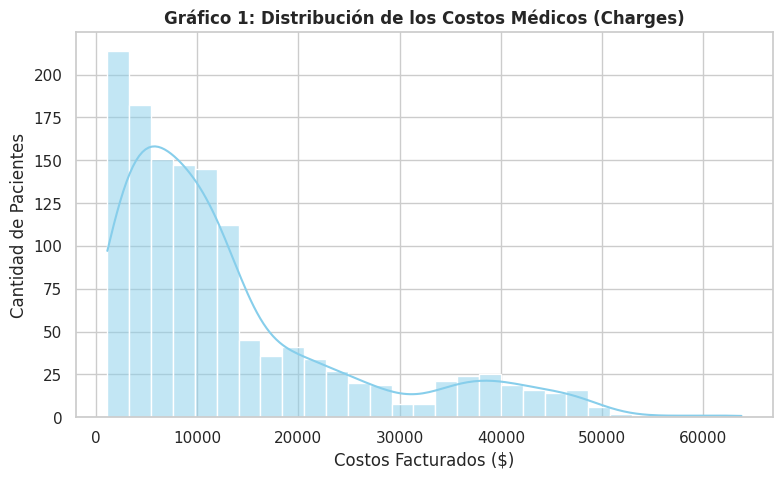

In [21]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='charges', kde=True, color='skyblue')

plt.title('Gráfico 1: Distribución de los Costos Médicos (Charges)', fontsize=12, fontweight='bold')
plt.xlabel('Costos Facturados ($)')
plt.ylabel('Cantidad de Pacientes')
plt.show()

Gráfico 2: Diagrama de Caja del IMC

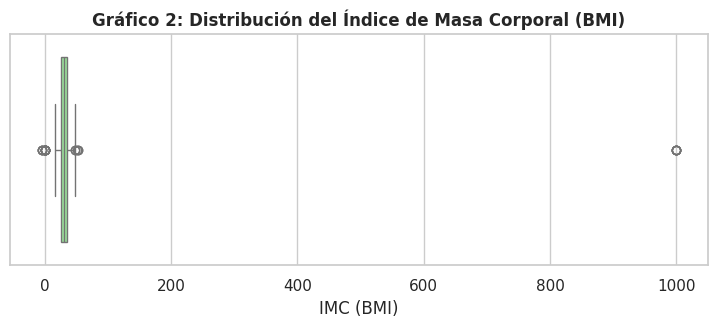

In [22]:
plt.figure(figsize=(9, 3))
sns.boxplot(data=df, x='bmi', color='lightgreen')

plt.title('Gráfico 2: Distribución del Índice de Masa Corporal (BMI)', fontsize=12, fontweight='bold')
plt.xlabel('IMC (BMI)')
plt.show()

Gráfico 3: Costos según si es Fumador

/tmp/ipykernel_5399/89764504.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smoker', y='charges', palette='Set2')


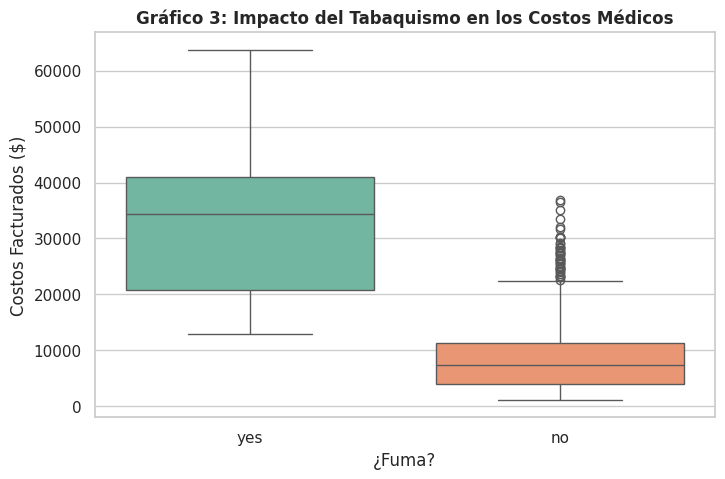

In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='smoker', y='charges', palette='Set2')

plt.title('Gráfico 3: Impacto del Tabaquismo en los Costos Médicos', fontsize=12, fontweight='bold')
plt.xlabel('¿Fuma?')
plt.ylabel('Costos Facturados ($)')
plt.show()

Gráfico 4: Dispersión de Edad vs. Costos

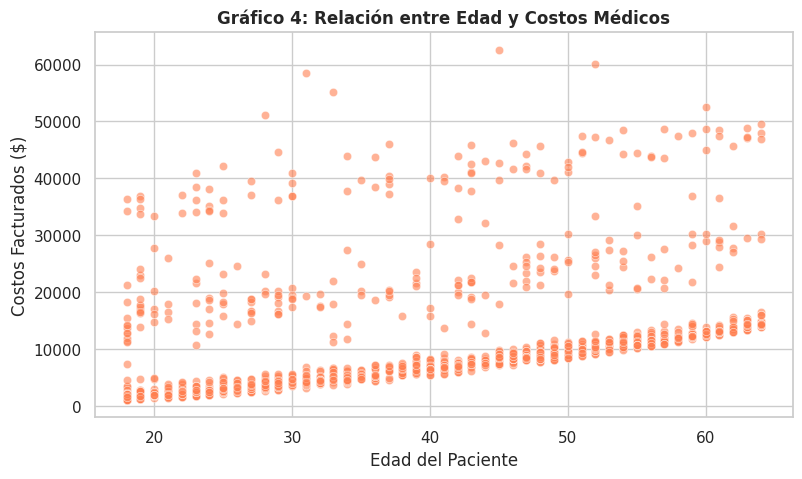

In [24]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='age', y='charges', alpha=0.6, color='coral')

plt.title('Gráfico 4: Relación entre Edad y Costos Médicos', fontsize=12, fontweight='bold')
plt.xlabel('Edad del Paciente')
plt.ylabel('Costos Facturados ($)')
plt.show()

Gráfico 5: Dispersión de IMC vs. Costos por Estado de Fumador

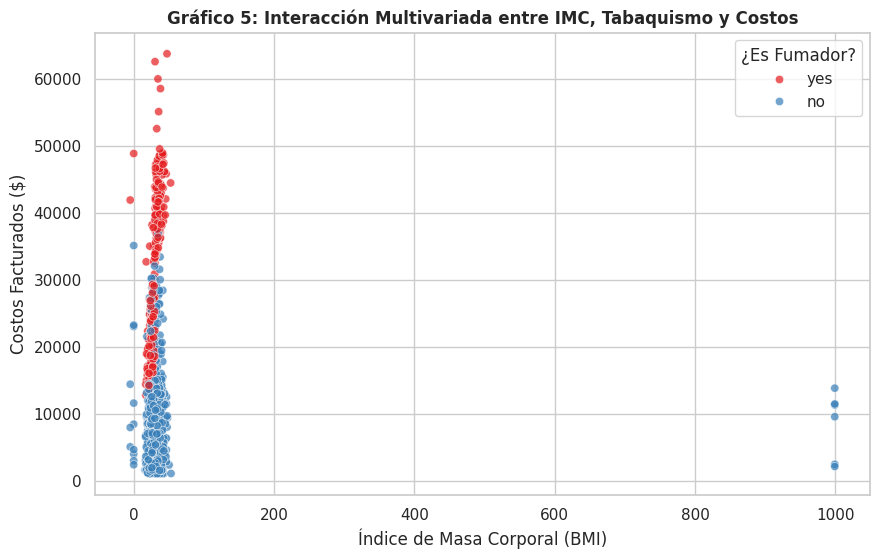

In [25]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', palette='Set1', alpha=0.7)

plt.title('Gráfico 5: Interacción Multivariada entre IMC, Tabaquismo y Costos', fontsize=12, fontweight='bold')
plt.xlabel('Índice de Masa Corporal (BMI)')
plt.ylabel('Costos Facturados ($)')
plt.legend(title='¿Es Fumador?')
plt.show()

Paso 6: Normalización y Reducción de Dimensionalidad (PCA).

In [26]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Configuración estética global
sns.set_theme(style="whitegrid")

# Carga inteligente de datos procesados
rutas_procesado = [
    '../data/processed/reporte_clinica_procesado.csv',
    'data/processed/reporte_clinica_procesado.csv',
    'reporte_clinica_procesado.csv'
]

df = None
for r in rutas_procesado:
    if os.path.exists(r):
        df = pd.read_csv(r)
        print("✅ Datos procesados cargados con éxito para PCA.")
        break

if df is None:
    raise FileNotFoundError("❌ No se encontró el dataset procesado. Corre primero el paso 2.")

✅ Datos procesados cargados con éxito para PCA.


In [27]:
# 1. Seleccionamos únicamente las variables numéricas del dataset
variables_numericas = ['age', 'bmi', 'children', 'charges']
X = df[variables_numericas]

# 2. Aplicamos el escalamiento estándar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertimos a DataFrame para verificar el escalamiento
df_scaled = pd.DataFrame(X_scaled, columns=variables_numericas)
print("--- Vista previa de los datos escalados (Media ≈ 0, Varianza ≈ 1) ---")
print(df_scaled.head())

--- Vista previa de los datos escalados (Media ≈ 0, Varianza ≈ 1) ---
        age       bmi  children   charges
0 -1.445130 -0.104531 -0.258529  0.297857
1 -1.516351 -0.016022 -0.077748 -0.954381
2 -0.804138 -0.027633  0.283814 -0.729373
3 -0.448031 -0.182862 -0.258529  0.719104
4 -0.519253 -0.089755 -0.258529 -0.777499


In [32]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Carga inteligente del dataset procesado
rutas_procesado = [
    '../data/processed/reporte_clinica_procesado.csv',
    'data/processed/reporte_clinica_procesado.csv',
    'reporte_clinica_procesado.csv'
]

df = None
for r in rutas_procesado:
    if os.path.exists(r):
        df = pd.read_csv(r)
        print("✅ Dataset procesado cargado para PCA.")
        break

if df is None:
    raise FileNotFoundError("❌ Asegúrate de correr el Paso 4 antes.")

# 2. Preparación de variables para el PCA
df_numeric = df[['age', 'bmi', 'children', 'charges']].copy()
df_numeric['is_smoker'] = df['smoker'].map({'no': 0, 'yes': 1})

# --- CORRECCIÓN DEL ERROR: Imputación de Valores Nulos ---
# Como age y bmi contienen nulos, los rellenamos con la mediana de cada columna
df_numeric['age'] = df_numeric['age'].fillna(df_numeric['age'].median())
df_numeric['bmi'] = df_numeric['bmi'].fillna(df_numeric['bmi'].median())

# 3. Escalamiento Obligatorio (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

print("📌 Valores nulos corregidos con la mediana. Variables listas y escaladas.")

✅ Dataset procesado cargado para PCA.
📌 Valores nulos corregidos con la mediana. Variables listas y escaladas.


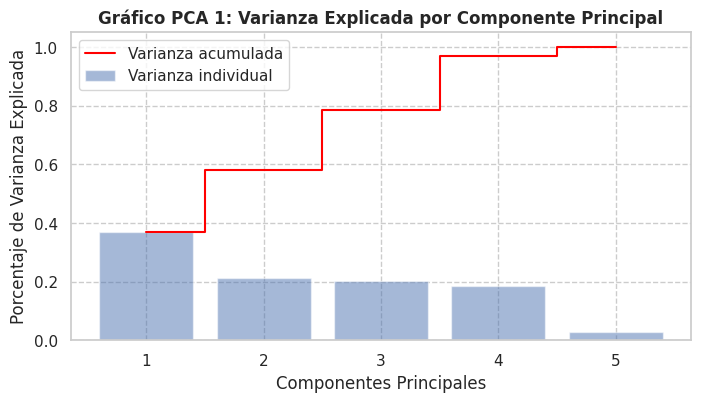

--- RESULTADOS TÉCNICOS ---
Componente Principal 1: explica el 36.95% de la varianza.
Componente Principal 2: explica el 21.16% de la varianza.
Componente Principal 3: explica el 20.26% de la varianza.
Componente Principal 4: explica el 18.64% de la varianza.
Componente Principal 5: explica el 2.98% de la varianza.

➡️ Las primeras 2 componentes explican el 58.11% de los datos totales.


In [33]:
# Aplicar PCA para todas las componentes posibles sobre los datos limpios y escalados
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Calcular varianza explicada acumulada
var_explicada = pca.explained_variance_ratio_
var_acumulada = np.cumsum(var_explicada)

# Gráfico 1: Varianza Explicada Acumulada (Scree Plot)
plt.figure(figsize=(8, 4))
plt.bar(range(1, len(var_explicada)+1), var_explicada, alpha=0.5, align='center', label='Varianza individual')
plt.step(range(1, len(var_acumulada)+1), var_acumulada, where='mid', label='Varianza acumulada', color='red')

plt.title('Gráfico PCA 1: Varianza Explicada por Componente Principal', fontsize=12, fontweight='bold')
plt.xlabel('Componentes Principales')
plt.ylabel('Porcentaje de Varianza Explicada')
plt.xticks(range(1, len(var_explicada)+1))
plt.legend(loc='best')
plt.grid(True, linestyle='--')
plt.show()

# Mostrar los valores exactos por consola
print("--- RESULTADOS TÉCNICOS ---")
for i, var in enumerate(var_explicada):
    print(f"Componente Principal {i+1}: explica el {var*100:.2f}% de la varianza.")
print(f"\n➡️ Las primeras 2 componentes explican el {var_acumulada[1]*100:.2f}% de los datos totales.")

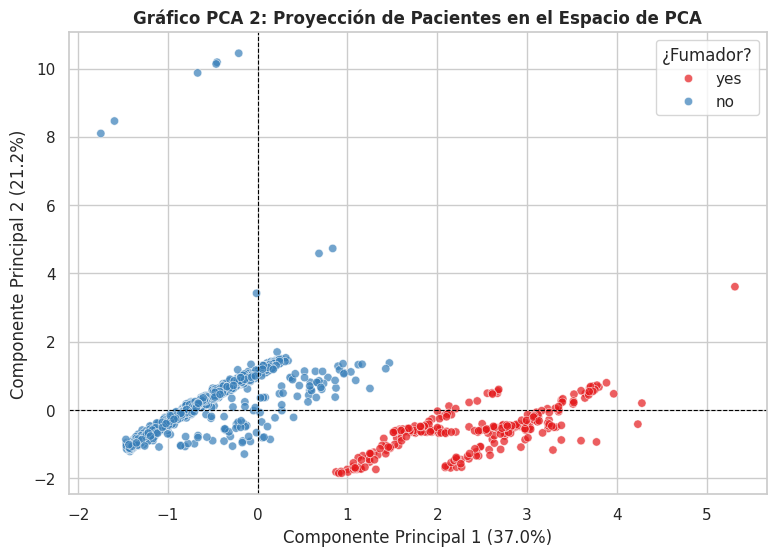

In [34]:
# Crear un DataFrame con las dos primeras componentes principales
df_pca = pd.DataFrame(data=X_pca[:, :2], columns=['PC1', 'PC2'])
df_pca['smoker'] = df['smoker'].values  # Conservamos la etiqueta original para colorear

# Gráfico 2: Biplot / Proyección de Pacientes en PC1 y PC2
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='smoker', palette='Set1', alpha=0.7)

plt.title('Gráfico PCA 2: Proyección de Pacientes en el Espacio de PCA', fontsize=12, fontweight='bold')
plt.xlabel(f'Componente Principal 1 ({var_explicada[0]*100:.1f}%)')
plt.ylabel(f'Componente Principal 2 ({var_explicada[1]*100:.1f}%)')
plt.legend(title='¿Fumador?')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.show()

Paso 7: Conclusiones del Proyecto Integrador

Respuesta a los Objetivos y Preguntas de Análisis

Basado en la evidencia recolectada a lo largo del pipeline de Minería de Datos, puedo concluir lo siguiente:

1.Distribución de Costos (Charges):
Evidencia: Los costos presentan una asimetría positiva severa, concentrándose la mayoría por debajo de los $15,000, pero con una cola que se extiende hasta superar los $40,000.

Interpretación: La mayor parte de la población genera un gasto base bajo y predecible, pero existe un grupo de alto riesgo que impacta de manera crítica en la facturación de la clínica.

2. Impacto del Tabaquismo:

Evidencia: La mediana de costos de pacientes fumadores ronda los $35,000, mientras que la de no fumadores no supera los $10,000. Además, el espacio de componentes principales (PCA) se dividió limpiamente de forma horizontal en función de esta variable.

Interpretación: El tabaquismo es el predictor individual más agresivo y determinante de los costos médicos elevados.

3.Interacción Multivariada (El Hallazgo Clave):

Evidencia: En los pacientes no fumadores, un IMC elevado (mayor a 30) no genera picos drásticos de costos. Sin embargo, en pacientes fumadores, cruzar la barrera de IMC = 30 dispara los costos de manera exponencial hasta los $60,000.

Interpretación: Existe un efecto de sinergia crítica: la combinación de obesidad y tabaquismo multiplica el riesgo médico y financiero de forma no lineal.

Limitaciones del Análisis

Cumpliendo con las pautas metodológicas de la cátedra, identifique las siguientes restricciones:

Calidad de los Datos Iniciales:  El alcance de las conclusiones se encuentra condicionado por la presencia de datos faltantes (nulos) en variables críticas como `age` (102 registros ausentes) y `bmi` (50 registros ausentes). Si bien se aplicó una imputación por mediana para preservar la estructura analítica, esto introduce un supuesto estadístico que podría suavizar la variabilidad real.

Falta de Contexto Clínico: El dataset carece de variables de antecedentes médicos (enfermedades preexistentes, historial familiar) o tipo de cobertura de seguro, lo que limita la capacidad de explicar las "tres bandas" observadas en el gráfico de Edad vs. Costos únicamente con las variables disponibles.

Mejoras Futuras

Para fortalecer y profundizar este análisis en fases posteriores del proyecto, se propone:

1. Incorporación de Datos Adicionales: Integrar información sobre el tipo de póliza contratada, hábitos de ejercicio o parámetros clínicos de laboratorio para explicar los residuos no capturados por el modelo actual.

2. Modelado Predictivo: Utilizar el dataset procesado (`reporte_clinica_procesado.csv`) como base para entrenar modelos de regresión supervisada (como Regresión Lineal o Árboles de Decisión) que permitan predecir los costos de nuevos pacientes en base a su perfil de riesgo.